# Notebook 81: Bifurcation Experiment

In [4]:
nb_id = 81

125 MESA runs of a 60 Msun, Z/Zsun=0.02 CHE star with hydrodynamics, varying only timestep controls
(varcontrol_target × time_delta_coeff × max_timestep_factor, 5³ grid). Despite identical physics and
enforced chemical homogeneity (Y_s/Y_c > 0.7), the HR tracks diverge: some go red, some stay blue.

This notebook implements four analyses:
1. Phase portrait — overlaid tracks colored by outcome
2. Outcome classification — histogram of final log_Teff at He depletion, blue/red threshold
3. Empirical committor function — probability of ending "red" as a function of (X_c, log_Teff)
4. Drift analysis / S-curve test — d(log_Teff)/d(X_c) vs log_Teff for bistability proof

## Setup

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic
import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import savefig_base

plt.style.use('plotstyle.mplstyle')

FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

DATA_PATH = Path(
    '/mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_dbg_production'
    '/00_fiducial/0002_ZdivZsun_2d-02/010_m60/fine_vct_tdc_mtf'
)

## Load all tracks

In [6]:
tracks = []
skipped_short = 0
skipped_no_hedep = 0

for subdir in sorted(DATA_PATH.iterdir()):
    if not subdir.is_dir() or subdir.name == 'template':
        continue
    history_path = subdir / 'LOGS' / 'history.data'
    if not history_path.exists():
        continue

    h = mr.MesaData(str(history_path))

    mn = h.model_number
    xc = h.center_h1
    xc_he = h.center_he4
    logTeff = h.log_Teff
    logR = h.log_R
    logL = h.log_L
    age = h.star_age

    # Deduplicate on model_number (MESA retries): keep last occurrence
    _, unique_idx = np.unique(mn[::-1], return_index=True)
    unique_idx = len(mn) - 1 - unique_idx  # flip back
    unique_idx = np.sort(unique_idx)

    mn = mn[unique_idx]
    xc = xc[unique_idx]
    xc_he = xc_he[unique_idx]
    logTeff = logTeff[unique_idx]
    logR = logR[unique_idx]
    logL = logL[unique_idx]
    age = age[unique_idx]

    if len(xc) < 50:
        skipped_short += 1
        continue

    # He-depletion endpoint: first model with center_he4 < 1e-3
    hedep_mask = xc_he < 1e-3
    if not np.any(hedep_mask):
        skipped_no_hedep += 1
        continue
    i_hedep = np.argmax(hedep_mask)  # first True
    end = i_hedep + 1  # include the He-depletion model

    xc = xc[:end]
    logTeff = logTeff[:end]
    logR = logR[:end]
    logL = logL[:end]
    age = age[:end]

    tracks.append({
        'name': subdir.name,
        'xc': xc,
        'logTeff': logTeff,
        'logR': logR,
        'logL': logL,
        'age': age,
    })

print(f'Loaded {len(tracks)} tracks')
print(f'Skipped: {skipped_short} too short, {skipped_no_hedep} no He depletion')
xc_min = min(t['xc'][-1] for t in tracks)
xc_max = max(t['xc'][0] for t in tracks)
print(f'Xc range: {xc_min:.4f} to {xc_max:.4f}')

Loaded 65 tracks
Skipped: 0 too short, 60 no He depletion
Xc range: 0.0000 to 0.7114


## Section 1: Phase Portrait

In [7]:
# Final log_Teff at He depletion for each track
final_logTeff = np.array([t['logTeff'][-1] for t in tracks])
final_logR = np.array([t['logR'][-1] for t in tracks])

norm_Teff = Normalize(vmin=final_logTeff.min(), vmax=final_logTeff.max())
cmap = plt.cm.coolwarm_r  # blue = hot (high logTeff), red = cool

In [8]:
# Identify splitting point: Xc where inter-track std(log_Teff) first exceeds 2x initial std
# Interpolate all tracks onto a common Xc grid
xc_common = np.linspace(xc_min, xc_max, 500)
logTeff_interp = np.full((len(tracks), len(xc_common)), np.nan)
logR_interp = np.full((len(tracks), len(xc_common)), np.nan)

for i, t in enumerate(tracks):
    xc_flip = t['xc'][::-1]
    mask = (xc_common >= t['xc'][-1]) & (xc_common <= t['xc'][0])
    logTeff_interp[i, mask] = np.interp(xc_common[mask], xc_flip, t['logTeff'][::-1])
    logR_interp[i, mask] = np.interp(xc_common[mask], xc_flip, t['logR'][::-1])

std_logTeff = np.nanstd(logTeff_interp, axis=0)
# Initial std: average of first 20 points where all tracks overlap
valid_counts = np.sum(~np.isnan(logTeff_interp), axis=0)
full_overlap = valid_counts == len(tracks)
if np.any(full_overlap):
    initial_std = np.nanmean(std_logTeff[full_overlap][:20])
else:
    initial_std = np.nanmean(std_logTeff[:20])

threshold_std = max(2 * initial_std, 0.01)
split_mask = std_logTeff > threshold_std
if np.any(split_mask):
    xc_star = xc_common[np.argmax(split_mask)]
else:
    xc_star = 0.3  # fallback
print(f'Splitting point X_c* ~ {xc_star:.3f} (initial std = {initial_std:.4f}, threshold = {threshold_std:.4f})')

Splitting point X_c* ~ 0.000 (initial std = 0.0468, threshold = 0.0936)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


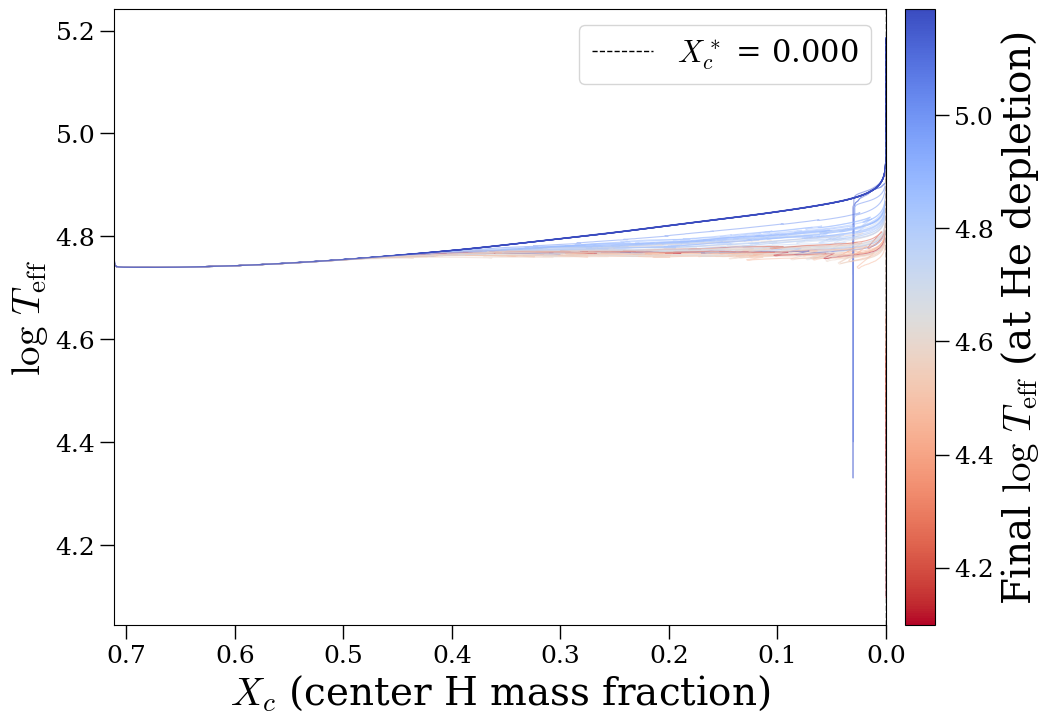

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
for t in tracks:
    color = cmap(norm_Teff(t['logTeff'][-1]))
    ax.plot(t['xc'], t['logTeff'], color=color, alpha=0.5, lw=0.8)
ax.axvline(xc_star, color='k', ls='--', lw=1, label=f'$X_c^*$ = {xc_star:.3f}')
ax.set_xlabel(r'$X_c$ (center H mass fraction)')
ax.set_ylabel(r'$\log\,T_{\rm eff}$')
ax.set_xlim(xc_max, xc_min)
ax.legend()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_Teff)
cb = fig.colorbar(sm, ax=ax, pad=0.02)
cb.set_label(r'Final $\log\,T_{\rm eff}$ (at He depletion)')
savefig(fig, 'fig01_phase_portrait_logTeff')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


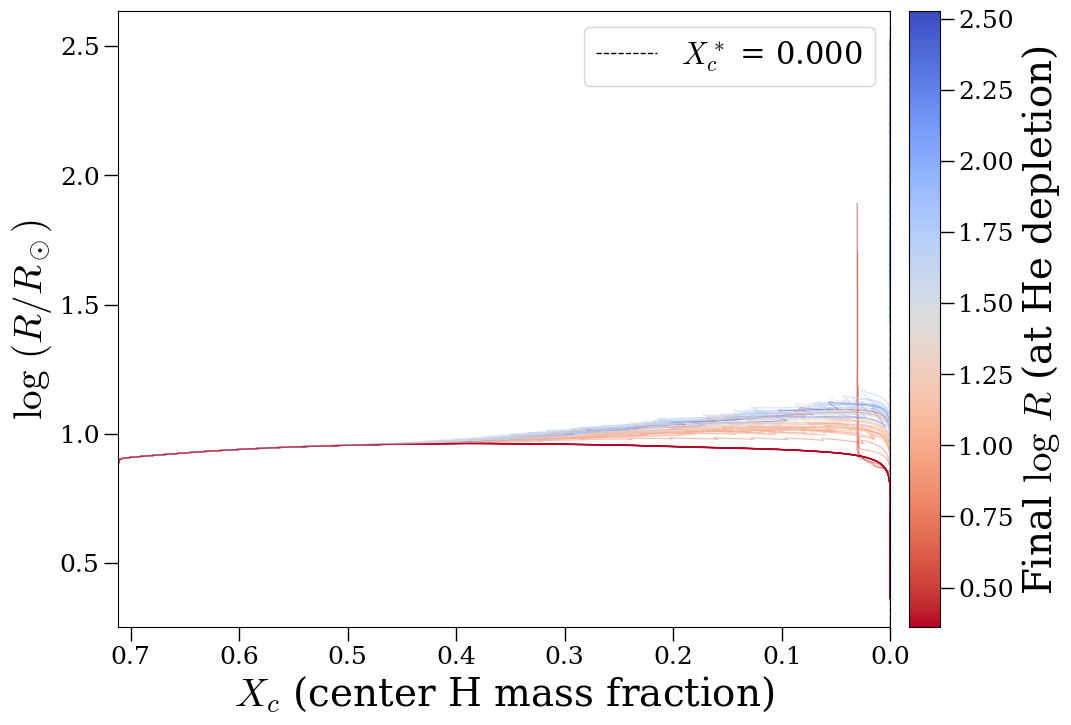

In [10]:
norm_R = Normalize(vmin=final_logR.min(), vmax=final_logR.max())

fig, ax = plt.subplots(figsize=(12, 8))
for t in tracks:
    color = cmap(norm_R(t['logR'][-1]))
    ax.plot(t['xc'], t['logR'], color=color, alpha=0.5, lw=0.8)
ax.axvline(xc_star, color='k', ls='--', lw=1, label=f'$X_c^*$ = {xc_star:.3f}')
ax.set_xlabel(r'$X_c$ (center H mass fraction)')
ax.set_ylabel(r'$\log\,(R/R_\odot)$')
ax.set_xlim(xc_max, xc_min)
ax.legend()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_R)
cb = fig.colorbar(sm, ax=ax, pad=0.02)
cb.set_label(r'Final $\log\,R$ (at He depletion)')
savefig(fig, 'fig02_phase_portrait_logR')
plt.show()

## Section 2: Outcome Classification

Bimodal: peaks at log_Teff = 4.660 and 4.878
Threshold log_Teff = 4.697


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


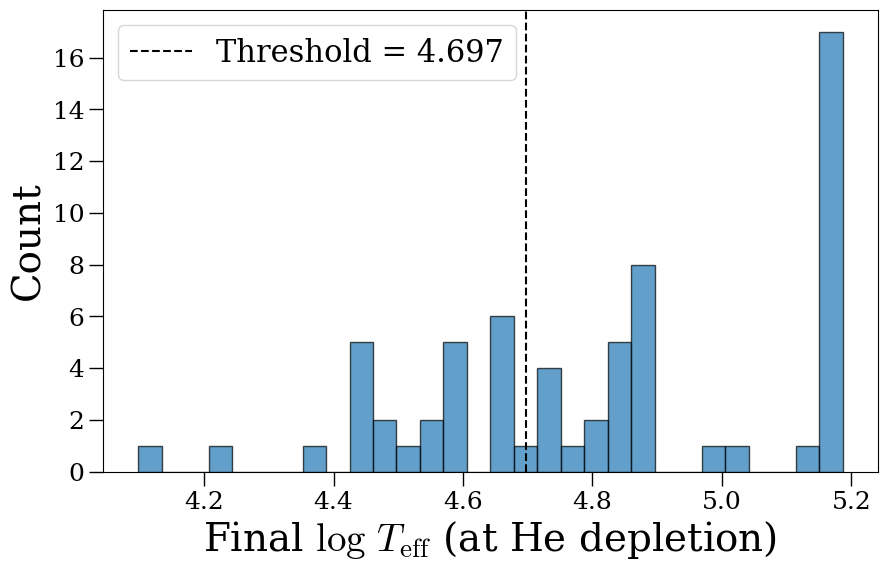

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(final_logTeff, bins=30, edgecolor='k', alpha=0.7)
ax.set_xlabel(r'Final $\log\,T_{\rm eff}$ (at He depletion)')
ax.set_ylabel('Count')

# Find threshold: look for the gap between modes
# Use a simple approach: find the histogram minimum between the two tallest bins
counts, bin_edges = np.histogram(final_logTeff, bins=30)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Find the two highest peaks
from scipy.signal import find_peaks
peaks, props = find_peaks(counts, height=1)
if len(peaks) >= 2:
    sorted_peaks = peaks[np.argsort(counts[peaks])[::-1]]
    p1, p2 = sorted(sorted_peaks[:2])
    # Threshold = bin center of the minimum between the two peaks
    valley = p1 + np.argmin(counts[p1:p2+1])
    logTeff_threshold = bin_centers[valley]
    print(f'Bimodal: peaks at log_Teff = {bin_centers[p1]:.3f} and {bin_centers[p2]:.3f}')
else:
    logTeff_threshold = np.median(final_logTeff)
    print('No clear bimodality detected; using median as threshold')

ax.axvline(logTeff_threshold, color='k', ls='--', lw=1.5, label=f'Threshold = {logTeff_threshold:.3f}')
ax.legend()
print(f'Threshold log_Teff = {logTeff_threshold:.3f}')
savefig(fig, 'fig03_histogram')
plt.show()

In [12]:
is_blue = final_logTeff > logTeff_threshold
n_blue = np.sum(is_blue)
n_red = np.sum(~is_blue)
print(f'Blue (hot): {n_blue}, Red (cool): {n_red}')

Blue (hot): 41, Red (cool): 24


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


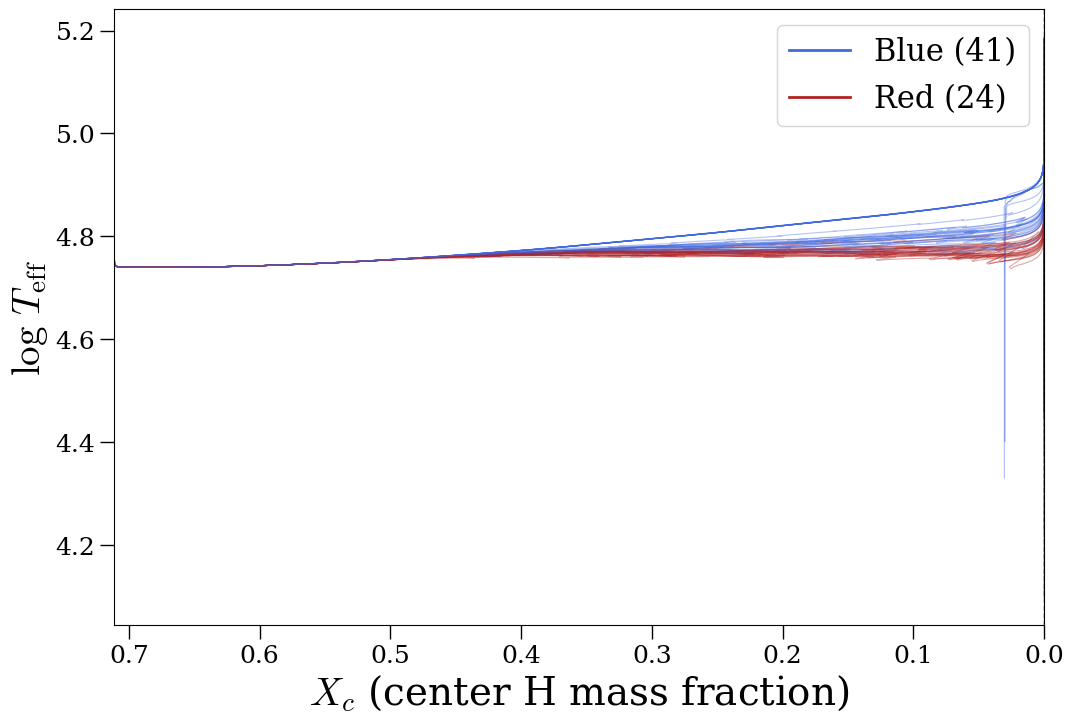

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
for i, t in enumerate(tracks):
    color = 'royalblue' if is_blue[i] else 'firebrick'
    ax.plot(t['xc'], t['logTeff'], color=color, alpha=0.4, lw=0.8)
ax.axvline(xc_star, color='k', ls='--', lw=1, label=f'$X_c^*$ = {xc_star:.3f}')
ax.set_xlabel(r'$X_c$ (center H mass fraction)')
ax.set_ylabel(r'$\log\,T_{\rm eff}$')
ax.set_xlim(xc_max, xc_min)
legend_handles = [
    Line2D([0], [0], color='royalblue', lw=2, label=f'Blue ({n_blue})'),
    Line2D([0], [0], color='firebrick', lw=2, label=f'Red ({n_red})'),
]
ax.legend(handles=legend_handles)
savefig(fig, 'fig04_classified_tracks')
plt.show()

## Section 3: Empirical Committor Function

The committor $p_B(X_c, \phi)$ is the probability that a track passing through the state $(X_c, \phi)$
ends up "red." We use $\phi = \log T_{\rm eff}$ as the order parameter.
The $p_B = 0.5$ contour is the separatrix.

In [14]:
n_xc_bins = 50
n_phi_bins = 40
min_count = 3

# Determine bin edges from the data range
all_logTeff = np.concatenate([t['logTeff'] for t in tracks])
all_xc = np.concatenate([t['xc'] for t in tracks])

xc_edges = np.linspace(all_xc.min(), all_xc.max(), n_xc_bins + 1)
phi_edges = np.linspace(all_logTeff.min(), all_logTeff.max(), n_phi_bins + 1)

count_total = np.zeros((n_xc_bins, n_phi_bins), dtype=int)
count_red = np.zeros((n_xc_bins, n_phi_bins), dtype=int)

for i, t in enumerate(tracks):
    ix = np.digitize(t['xc'], xc_edges) - 1
    iy = np.digitize(t['logTeff'], phi_edges) - 1
    ix = np.clip(ix, 0, n_xc_bins - 1)
    iy = np.clip(iy, 0, n_phi_bins - 1)
    # Mark each unique bin this track passes through
    visited = set(zip(ix, iy))
    for (bx, by) in visited:
        count_total[bx, by] += 1
        if not is_blue[i]:
            count_red[bx, by] += 1

committor = np.full((n_xc_bins, n_phi_bins), np.nan)
mask = count_total >= min_count
committor[mask] = count_red[mask] / count_total[mask]

print(f'Bins with >= {min_count} tracks: {np.sum(mask)} / {n_xc_bins * n_phi_bins}')

Bins with >= 3 tracks: 140 / 2000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


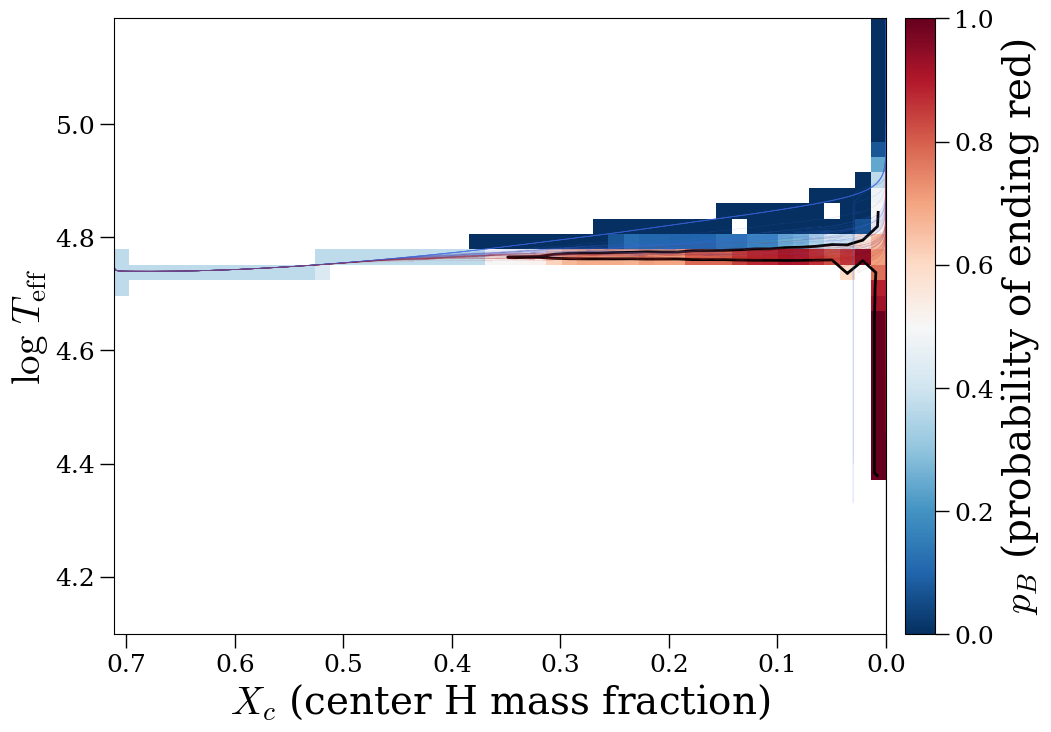

In [15]:
xc_centers = 0.5 * (xc_edges[:-1] + xc_edges[1:])
phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
XC, PHI = np.meshgrid(xc_centers, phi_centers, indexing='ij')

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.pcolormesh(xc_centers, phi_centers, committor.T,
                   cmap='RdBu_r', vmin=0, vmax=1, shading='auto')
# Separatrix contour
committor_plot = committor.copy()
committor_plot[np.isnan(committor_plot)] = -1  # avoid contour issues
ax.contour(xc_centers, phi_centers, committor_plot.T,
           levels=[0.5], colors='k', linewidths=2)
# Overlay tracks
for i, t in enumerate(tracks):
    color = 'royalblue' if is_blue[i] else 'firebrick'
    ax.plot(t['xc'], t['logTeff'], color=color, alpha=0.15, lw=0.5)
ax.set_xlabel(r'$X_c$ (center H mass fraction)')
ax.set_ylabel(r'$\log\,T_{\rm eff}$')
ax.set_xlim(xc_max, xc_min)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r'$p_B$ (probability of ending red)')
savefig(fig, 'fig05_committor')
plt.show()

In [16]:
# Committor statistics
valid = committor[mask]
n_near_05 = np.sum(np.abs(valid - 0.5) < 0.1)
print(f'Bins with p_B in [0.4, 0.6]: {n_near_05} / {len(valid)}')
print(f'Committor range: {np.nanmin(valid):.3f} to {np.nanmax(valid):.3f}')

Bins with p_B in [0.4, 0.6]: 12 / 140
Committor range: 0.000 to 1.000


## Section 4: Drift Analysis — The S-curve Test

At fixed $X_c$ slices near the bifurcation point, compute the "drift" $d(\log T_{\rm eff})/d(X_c)$
for each track. If the drift curve crosses zero three times (positive–negative–positive or vice versa),
this is definitive proof of bistability.

In [17]:
# Compute drift d(log_Teff)/d(Xc) and d(log_R)/d(Xc) for each track
for t in tracks:
    dx = np.diff(t['xc'])
    # Avoid division by zero
    dx[dx == 0] = np.nan
    t['drift_logTeff'] = np.diff(t['logTeff']) / dx
    t['drift_logR'] = np.diff(t['logR']) / dx
    # Midpoints for the drift values
    t['xc_mid'] = 0.5 * (t['xc'][:-1] + t['xc'][1:])

In [18]:
# Choose Xc slices around the splitting point
offsets = [-0.05, -0.025, 0.0, 0.025, 0.05]
xc_slices = [xc_star + off for off in offsets]
# Ensure slices are within data range
xc_slices = [x for x in xc_slices if xc_min < x < xc_max]
print(f'X_c slices: {[f"{x:.3f}" for x in xc_slices]}')

def interpolate_at_xc(tracks, xc_val, var='logTeff'):
    """Interpolate each track's variable and its drift at a fixed Xc."""
    phi_vals = []
    drift_vals = []
    blue_flags = []
    for i, t in enumerate(tracks):
        if t['xc'][-1] > xc_val or t['xc'][0] < xc_val:
            continue  # track doesn't span this Xc
        # Flip for np.interp (needs increasing x)
        xc_flip = t['xc'][::-1]
        phi = np.interp(xc_val, xc_flip, t[var][::-1])
        xc_mid_flip = t['xc_mid'][::-1]
        drift = np.interp(xc_val, xc_mid_flip, t[f'drift_{var}'][::-1])
        phi_vals.append(phi)
        drift_vals.append(drift)
        blue_flags.append(is_blue[i])
    return np.array(phi_vals), np.array(drift_vals), np.array(blue_flags)

X_c slices: ['0.025', '0.050']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


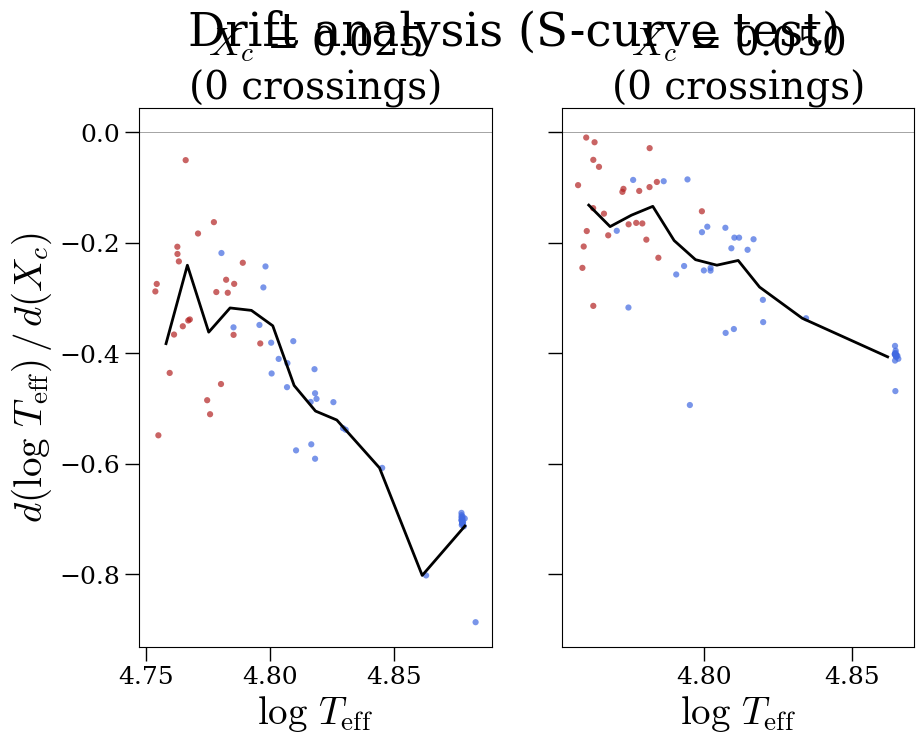

Slices with S-curve signature (>= 2 zero crossings): 0 / 2


In [19]:
n_slices = len(xc_slices)
fig, axes = plt.subplots(1, n_slices, figsize=(5 * n_slices, 7), sharey=True)
if n_slices == 1:
    axes = [axes]

n_scurve = 0
for ax, xc_val in zip(axes, xc_slices):
    phi, drift, bf = interpolate_at_xc(tracks, xc_val, 'logTeff')
    if len(phi) < 5:
        ax.set_title(f'$X_c$ = {xc_val:.3f}\n(too few tracks)')
        continue

    colors = np.where(bf, 'royalblue', 'firebrick')
    ax.scatter(phi, drift, c=colors, s=20, alpha=0.7, edgecolors='none')
    ax.axhline(0, color='gray', ls='-', lw=0.5)

    # Binned-mean smooth curve
    n_smooth_bins = min(15, len(phi) // 3)
    if n_smooth_bins >= 3:
        sort_idx = np.argsort(phi)
        phi_sorted = phi[sort_idx]
        drift_sorted = drift[sort_idx]
        bin_means, bin_edges_s, _ = binned_statistic(
            phi_sorted, drift_sorted, statistic='mean', bins=n_smooth_bins)
        bin_centers_s = 0.5 * (bin_edges_s[:-1] + bin_edges_s[1:])
        valid_s = ~np.isnan(bin_means)
        ax.plot(bin_centers_s[valid_s], bin_means[valid_s], 'k-', lw=2)

        # Count zero crossings in the smoothed curve
        bm_valid = bin_means[valid_s]
        sign_changes = np.sum(np.diff(np.sign(bm_valid)) != 0)
        if sign_changes >= 2:
            n_scurve += 1
            ax.set_title(f'$X_c$ = {xc_val:.3f}\n({sign_changes} crossings)', color='green')
        else:
            ax.set_title(f'$X_c$ = {xc_val:.3f}\n({sign_changes} crossings)')
    else:
        ax.set_title(f'$X_c$ = {xc_val:.3f}')

    ax.set_xlabel(r'$\log\,T_{\rm eff}$')

axes[0].set_ylabel(r'$d(\log\,T_{\rm eff}) \,/\, d(X_c)$')
fig.suptitle('Drift analysis (S-curve test)', y=1.02)
savefig(fig, 'fig06_scurve_logTeff')
plt.show()
print(f'Slices with S-curve signature (>= 2 zero crossings): {n_scurve} / {n_slices}')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


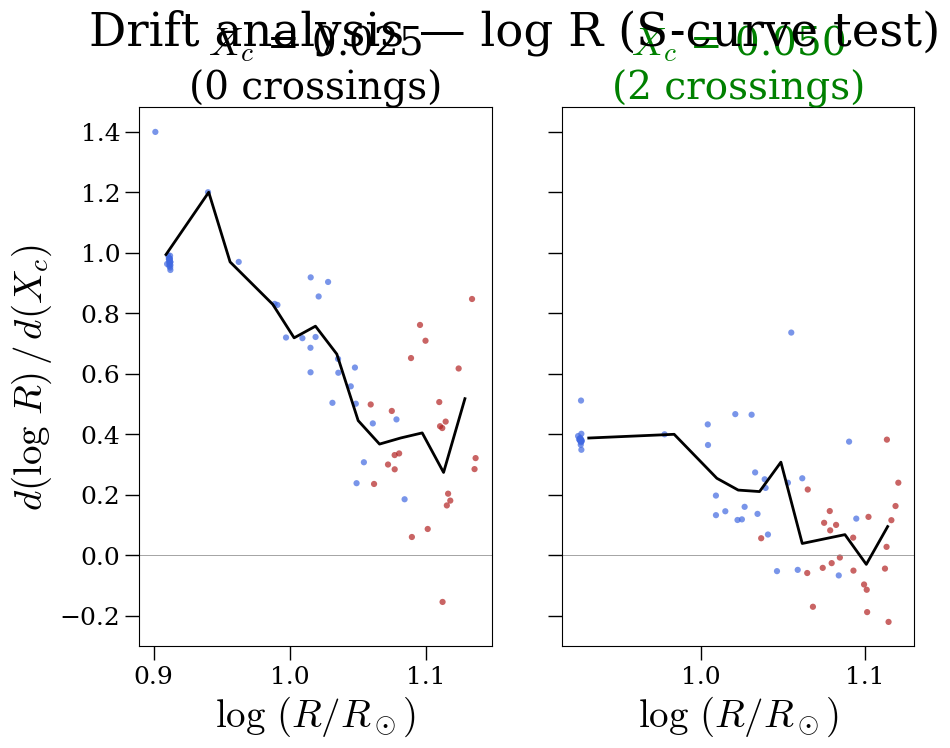

Slices with S-curve signature (>= 2 zero crossings): 1 / 2


In [20]:
# Same drift analysis using log_R
fig, axes = plt.subplots(1, n_slices, figsize=(5 * n_slices, 7), sharey=True)
if n_slices == 1:
    axes = [axes]

n_scurve_R = 0
for ax, xc_val in zip(axes, xc_slices):
    phi, drift, bf = interpolate_at_xc(tracks, xc_val, 'logR')
    if len(phi) < 5:
        ax.set_title(f'$X_c$ = {xc_val:.3f}\n(too few tracks)')
        continue

    colors = np.where(bf, 'royalblue', 'firebrick')
    ax.scatter(phi, drift, c=colors, s=20, alpha=0.7, edgecolors='none')
    ax.axhline(0, color='gray', ls='-', lw=0.5)

    n_smooth_bins = min(15, len(phi) // 3)
    if n_smooth_bins >= 3:
        sort_idx = np.argsort(phi)
        phi_sorted = phi[sort_idx]
        drift_sorted = drift[sort_idx]
        bin_means, bin_edges_s, _ = binned_statistic(
            phi_sorted, drift_sorted, statistic='mean', bins=n_smooth_bins)
        bin_centers_s = 0.5 * (bin_edges_s[:-1] + bin_edges_s[1:])
        valid_s = ~np.isnan(bin_means)
        ax.plot(bin_centers_s[valid_s], bin_means[valid_s], 'k-', lw=2)

        bm_valid = bin_means[valid_s]
        sign_changes = np.sum(np.diff(np.sign(bm_valid)) != 0)
        if sign_changes >= 2:
            n_scurve_R += 1
            ax.set_title(f'$X_c$ = {xc_val:.3f}\n({sign_changes} crossings)', color='green')
        else:
            ax.set_title(f'$X_c$ = {xc_val:.3f}\n({sign_changes} crossings)')
    else:
        ax.set_title(f'$X_c$ = {xc_val:.3f}')

    ax.set_xlabel(r'$\log\,(R/R_\odot)$')

axes[0].set_ylabel(r'$d(\log\,R) \,/\, d(X_c)$')
fig.suptitle('Drift analysis — log R (S-curve test)', y=1.02)
savefig(fig, 'fig07_scurve_logR')
plt.show()
print(f'Slices with S-curve signature (>= 2 zero crossings): {n_scurve_R} / {n_slices}')

## Summary

In [21]:
print('=== Bifurcation Experiment Summary ===')
print(f'Tracks loaded: {len(tracks)}')
print(f'Xc range: {xc_min:.4f} to {xc_max:.4f}')
print(f'Splitting point X_c* ~ {xc_star:.3f}')
print(f'Classification: {n_blue} blue, {n_red} red (threshold log_Teff = {logTeff_threshold:.3f})')
print(f'S-curve (log_Teff): {n_scurve} / {n_slices} slices show >= 2 zero crossings')
print(f'S-curve (log_R):    {n_scurve_R} / {n_slices} slices show >= 2 zero crossings')

=== Bifurcation Experiment Summary ===
Tracks loaded: 65
Xc range: 0.0000 to 0.7114
Splitting point X_c* ~ 0.000
Classification: 41 blue, 24 red (threshold log_Teff = 4.697)
S-curve (log_Teff): 0 / 2 slices show >= 2 zero crossings
S-curve (log_R):    1 / 2 slices show >= 2 zero crossings
